# Análisis Cluster - Fórmula 1

En este notebook se realiza el **Análisis Cluster** del trabajo práctico.

Se comparan dos enfoques, como pidió el profesor:

1. **Clustering sin PCA:** se trabaja directamente con las variables numéricas seleccionadas del `df_model`, luego de escalarlas.
2. **Clustering con PCA:** se trabaja con la matriz de componentes principales guardada en el notebook anterior.

La idea no es solamente obtener etiquetas de cluster, sino también **comparar si los grupos cambian cuando se usa PCA** y describirlos en términos del problema: rendimiento posicional, vueltas completadas, edad del piloto y características del circuito.

## 1. Criterio general del análisis

El análisis cluster busca asignar observaciones a grupos tales que sean:

- **homogéneos internamente:** observaciones parecidas dentro del mismo grupo;
- **heterogéneos externamente:** observaciones diferentes entre grupos.

Para eso hay que tomar varias decisiones:

1. qué variables usar;
2. cómo medir cercanía entre observaciones;
3. qué algoritmo usar;
4. cómo elegir la cantidad de clusters;
5. cómo describir los grupos resultantes.

En este notebook se usa principalmente **distancia euclídea** sobre matrices numéricas. Para el caso sin PCA, las variables se escalan con **MinMaxScaler** para equilibrar su influencia en la distancia. Para el caso con PCA, se usan los scores de las componentes principales previamente guardados.

## 2. Importar librerías y definir rutas

In [68]:
# Para evitar que algunos cálculos de sklearn/numpy saturen la máquina local.
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics.pairwise import euclidean_distances

from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree, cophenet
from scipy.spatial.distance import squareform

try:
    from threadpoolctl import threadpool_limits
    threadpool_limits(1)
except Exception:
    pass

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

In [69]:
def encontrar_raiz_proyecto():
    """Busca hacia arriba una carpeta que contenga data/processed."""
    actual = Path.cwd().resolve()
    candidatos = [actual] + list(actual.parents)
    for carpeta in candidatos:
        if (carpeta / "data" / "processed").exists():
            return carpeta
    # Si no se encuentra, se asume que estamos en la raíz del proyecto.
    return actual

PROJECT_DIR = encontrar_raiz_proyecto()
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_DIR / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:", PROJECT_DIR)
print("Carpeta processed:", PROCESSED_DIR)
print("Carpeta de figuras:", FIGURES_DIR)

Raíz del proyecto: /Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado
Carpeta processed: /Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado/data/processed
Carpeta de figuras: /Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado/reports/figures


## 3. Funciones auxiliares

Se definen funciones para:

- calcular la **Gap Statistic**;
- evaluar K-Means con método del codo, silhouette y Gap;
- graficar diagnósticos;
- aplicar clustering jerárquico en una muestra;
- resumir perfiles numéricos y categóricos de los clusters.

In [70]:
def calculate_gap_statistic(data, max_k=10, n_references=5, random_state=42):
    """
    Calcula la Gap Statistic para K-Means.

    Devuelve:
    - gaps: valores Gap(k)
    - s_k: desvío corregido
    - optimal_k: menor k que cumple Gap(k) >= Gap(k+1) - s(k+1)

    Para datasets medianos/grandes conviene aplicarla sobre una muestra.
    """
    if hasattr(data, "values"):
        data = data.values

    rng = np.random.default_rng(random_state)
    ks = range(1, max_k + 1)
    gaps = np.zeros(max_k)
    s_k = np.zeros(max_k)

    mins = data.min(axis=0)
    maxs = data.max(axis=0)

    for idx, k in enumerate(ks):
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        km.fit(data)
        log_w = np.log(km.inertia_) if km.inertia_ > 0 else 0

        log_w_refs = np.zeros(n_references)
        for b in range(n_references):
            random_data = rng.random(size=data.shape) * (maxs - mins) + mins
            km_ref = KMeans(n_clusters=k, random_state=random_state, n_init=10)
            km_ref.fit(random_data)
            log_w_refs[b] = np.log(km_ref.inertia_) if km_ref.inertia_ > 0 else 0

        gaps[idx] = np.mean(log_w_refs) - log_w
        s_k[idx] = np.std(log_w_refs, ddof=0) * np.sqrt(1 + 1.0 / n_references)

    optimal_k = max_k
    for i in range(len(ks) - 1):
        if gaps[i] >= gaps[i + 1] - s_k[i + 1]:
            optimal_k = i + 1
            break

    return gaps, s_k, optimal_k


def evaluar_kmeans(X, k_min=2, k_max=10, sample_size=1500, random_state=42, n_references_gap=5):
    """
    Evalúa K-Means para varios k.

    Se ajusta K-Means sobre una muestra para que el notebook sea liviano.
    Luego el modelo final se ajusta sobre todos los datos.
    """
    X = np.asarray(X)
    n = X.shape[0]

    if sample_size is not None and n > sample_size:
        rng = np.random.default_rng(random_state)
        idx_eval = rng.choice(n, size=sample_size, replace=False)
        X_eval = X[idx_eval]
    else:
        idx_eval = np.arange(n)
        X_eval = X

    ks = list(range(k_min, k_max + 1))
    inercias = []
    silhouettes = []
    min_cluster_prop = []

    for k in ks:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=20)
        labels = km.fit_predict(X_eval)
        inercias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_eval, labels, metric="euclidean"))
        counts = np.bincount(labels)
        min_cluster_prop.append(counts.min() / counts.sum())

    gaps, s_k, k_gap = calculate_gap_statistic(
        X_eval, max_k=k_max, n_references=n_references_gap, random_state=random_state
    )

    resultados = pd.DataFrame({
        "k": ks,
        "inercia": inercias,
        "silhouette": silhouettes,
        "proporcion_cluster_mas_chico": min_cluster_prop,
        "gap": gaps[k_min-1:k_max],
        "gap_menos_s": (gaps - s_k)[k_min-1:k_max]
    })

    # Sugerencia: mejor silhouette entre soluciones sin clusters demasiado chicos.
    # El umbral evita elegir una partición sólo porque separa un micro-grupo de outliers.
    candidatas = resultados[resultados["proporcion_cluster_mas_chico"] >= 0.03]
    if len(candidatas) > 0:
        k_sugerido = int(candidatas.sort_values("silhouette", ascending=False).iloc[0]["k"])
    else:
        k_sugerido = int(resultados.sort_values("silhouette", ascending=False).iloc[0]["k"])

    resumen = {
        "k_silhouette_sugerido": k_sugerido,
        "k_gap": int(k_gap),
        "n_eval": X_eval.shape[0],
        "idx_eval": idx_eval
    }

    return resultados, resumen


def plot_diagnosticos_kmeans(resultados, titulo, guardar_como=None):
    fig, axs = plt.subplots(1, 3, figsize=(18, 4))

    axs[0].plot(resultados["k"], resultados["inercia"], marker="o")
    axs[0].set_title("Método del codo")
    axs[0].set_xlabel("Número de clusters")
    axs[0].set_ylabel("WCSS / inercia")

    axs[1].plot(resultados["k"], resultados["silhouette"], marker="o")
    axs[1].set_title("Silhouette score")
    axs[1].set_xlabel("Número de clusters")
    axs[1].set_ylabel("Silhouette")

    axs[2].plot(resultados["k"], resultados["gap"], marker="o", label="Gap")
    axs[2].scatter(resultados["k"], resultados["gap_menos_s"], marker="x", label="Gap - s(k)")
    axs[2].set_title("Gap Statistic")
    axs[2].set_xlabel("Número de clusters")
    axs[2].set_ylabel("Gap")
    axs[2].legend()

    fig.suptitle(titulo, y=1.05, fontsize=14)
    plt.tight_layout()

    if guardar_como is not None:
        plt.savefig(FIGURES_DIR / guardar_como, dpi=150, bbox_inches="tight")

    plt.show()


def ajustar_kmeans_final(X, k, nombre_cluster, random_state=42):
    km = KMeans(n_clusters=k, random_state=random_state, n_init=50)
    labels = km.fit_predict(X)
    print(f"Tamaño de clusters para {nombre_cluster}:")
    display(pd.Series(labels).value_counts().sort_index().rename("n").to_frame())
    return km, labels


def analisis_jerarquico_muestra(X, k_final, titulo, sample_size=800, random_state=42, guardar_como=None):
    """
    Replica la lógica de la práctica: distancias euclídeas, dendrogramas,
    silhouette por encadenamiento y coeficiente cofenético.

    Se trabaja sobre una muestra para evitar problemas de memoria y para que
    el dendrograma sea legible.
    """
    X = np.asarray(X)
    n = X.shape[0]
    rng = np.random.default_rng(random_state)

    if n > sample_size:
        idx = rng.choice(n, size=sample_size, replace=False)
        X_sample = X[idx]
    else:
        idx = np.arange(n)
        X_sample = X

    D = euclidean_distances(X_sample, X_sample)
    condensed_D = squareform(D, checks=False)

    Zs = {
        "simple": linkage(condensed_D, method="single"),
        "completo": linkage(condensed_D, method="complete"),
        "promedio": linkage(condensed_D, method="average"),
        "ward": linkage(condensed_D, method="ward")
    }

    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    for ax, (nombre, Z) in zip(axs.ravel(), Zs.items()):
        dendrogram(Z, ax=ax, no_labels=True, color_threshold=None)
        ax.set_title(f"Encadenamiento {nombre}")
        ax.set_xlabel("Observaciones de la muestra")
        ax.set_ylabel("Altura")
    fig.suptitle(titulo, y=1.02)
    plt.tight_layout()

    if guardar_como is not None:
        plt.savefig(FIGURES_DIR / guardar_como, dpi=150, bbox_inches="tight")

    plt.show()

    k_range = range(2, 11)
    sil_rows = []
    for nombre, Z in Zs.items():
        for k in k_range:
            labels = cut_tree(Z, n_clusters=k).reshape(-1)
            sil = silhouette_score(D, labels, metric="precomputed")
            sil_rows.append({"encadenamiento": nombre, "k": k, "silhouette": sil})
    sil_df = pd.DataFrame(sil_rows)

    plt.figure(figsize=(9, 5))
    sns.lineplot(data=sil_df, x="k", y="silhouette", hue="encadenamiento", marker="o")
    plt.title(f"Silhouette por encadenamiento - {titulo}")
    plt.xlabel("Número de clusters")
    plt.ylabel("Silhouette")
    plt.tight_layout()
    plt.show()

    ccc = []
    for nombre, Z in Zs.items():
        valor, _ = cophenet(Z, condensed_D)
        ccc.append({"encadenamiento": nombre, "coeficiente_cofenetico": valor})
    ccc_df = pd.DataFrame(ccc).sort_values("coeficiente_cofenetico", ascending=False)

    labels_ward = cut_tree(Zs["ward"], n_clusters=k_final).reshape(-1)
    print(f"Tamaño de clusters Ward en muestra, k={k_final}:")
    display(pd.Series(labels_ward).value_counts().sort_index().rename("n").to_frame())

    return {
        "idx_muestra": idx,
        "D": D,
        "Zs": Zs,
        "silhouette": sil_df,
        "cofenetico": ccc_df,
        "labels_ward_muestra": labels_ward
    }


def perfil_numerico(df, cluster_col, variables):
    resumen = (
        df.groupby(cluster_col)[variables]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .round(3)
    )
    return resumen


def perfil_categorico(df, cluster_col, variable_cat):
    tabla = pd.crosstab(df[cluster_col], df[variable_cat], normalize="index").round(3)
    return tabla


def plot_boxplots_clusters(df, cluster_col, variables, titulo, guardar_como=None):
    n_vars = len(variables)
    n_cols = 3
    n_rows = int(np.ceil(n_vars / n_cols))
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axs = np.array(axs).reshape(-1)

    for ax, var in zip(axs, variables):
        sns.boxplot(data=df, x=cluster_col, y=var, hue=cluster_col, legend=False, ax=ax)
        ax.set_title(var)
        ax.set_xlabel("Cluster")
    for ax in axs[len(variables):]:
        ax.axis("off")

    fig.suptitle(titulo, y=1.02)
    plt.tight_layout()

    if guardar_como is not None:
        plt.savefig(FIGURES_DIR / guardar_como, dpi=150, bbox_inches="tight")

    plt.show()


def plot_categorica_fill(df, cluster_col, variable_cat, titulo, guardar_como=None):
    tabla = pd.crosstab(df[cluster_col], df[variable_cat], normalize="index")
    ax = tabla.plot(kind="bar", stacked=True, figsize=(10, 5))
    ax.set_title(titulo)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Proporción")
    ax.legend(title=variable_cat, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    if guardar_como is not None:
        plt.savefig(FIGURES_DIR / guardar_como, dpi=150, bbox_inches="tight")

    plt.show()

## 4. Cargar `df_model`

Se intenta usar el `df_model` que ya exista en memoria. Si no existe, se carga la base procesada generada en el EDA.

In [71]:
try:
    df_model
    print("Se usa df_model existente en memoria.")
except NameError:
    ruta_base = PROCESSED_DIR / "formula1_base_trabajo.csv"
    if not ruta_base.exists():
        raise FileNotFoundError(
            "No existe df_model en memoria ni se encontró data/processed/formula1_base_trabajo.csv. "
            "Primero corré el notebook de EDA."
        )
    df_model = pd.read_csv(ruta_base)
    print("Se cargó df_model desde:", ruta_base)

print("Dimensiones de df_model:", df_model.shape)
display(df_model.head())

Se usa df_model existente en memoria.
Dimensiones de df_model: (10000, 40)


,year,decada,round,race_name,race_date,circuit_name,circuit_country,circuit_location,driver_name,driver_nationality,driver_age,constructor_name,constructor_nationality,grid,largada_grupo,positionOrder,resultado_grupo,race_points,laps,status,status_grupo,driver_championship_points,driver_championship_position,driver_championship_wins,resultId,raceId,driverId,constructorId,statusId,circuitId,driverRef,dob,constructorRef,circuitRef,circuit_lat,circuit_lng,circuit_alt,podio,top10,victoria
0,2024,2020s,12,British Grand Prix,2024-07-07,Silverstone Circuit,UK,Silverstone,Oscar Piastri,Australian,23.252567,McLaren,British,5,Top 5,4,Top 10,12.0,52,Finished,Clasificado / terminó,124.0,5.0,0.0,26508,1132,857,1,1,9,piastri,2001-04-06,mclaren,silverstone,52.07860,-1.01694,153,0,1,0
1,2008,2000s,2,Malaysian Grand Prix,2008-03-23,Sepang International Circuit,Malaysia,Kuala Lumpur,Giancarlo Fisichella,Italian,35.186858,Force India,Indian,17,Fondo,12,Fuera del top 10,0.0,55,+1 Lap,Clasificado / terminó,0.0,15.0,0.0,34,19,21,10,11,2,fisichella,1973-01-14,force_india,sepang,2.76083,101.73800,18,0,0,0
2,2005,2000s,12,German Grand Prix,2005-07-24,Hockenheimring,Germany,Hockenheim,Narain Karthikeyan,Indian,28.522930,Jordan,Irish,19,Fondo,16,Fuera del top 10,0.0,64,+3 Laps,Clasificado / terminó,5.0,17.0,0.0,1370,82,39,17,13,10,karthikeyan,1977-01-14,jordan,hockenheimring,49.32780,8.56583,103,0,0,0
3,2009,2000s,16,Brazilian Grand Prix,2009-10-18,Autódromo José Carlos Pace,Brazil,São Paulo,Adrian Sutil,German,26.767967,Force India,Indian,3,Top 5,18,Fuera del top 10,0.0,0,Accident,Incidente / abandono,5.0,16.0,0.0,7871,16,16,10,3,18,sutil,1983-01-11,force_india,interlagos,-23.70360,-46.69970,785,0,0,0
4,2000,2000s,16,Japanese Grand Prix,2000-10-08,Suzuka Circuit,Japan,Suzuka,Giancarlo Fisichella,Italian,27.731691,Benetton,Italian,12,Fondo,14,Fuera del top 10,0.0,52,+1 Lap,Clasificado / terminó,18.0,6.0,0.0,3273,173,21,22,11,22,fisichella,1973-01-14,benetton,suzuka,34.84310,136.54100,45,0,0,0


## 5. Selección de variables para clustering sin PCA

Para que la comparación sea justa, el clustering sin PCA usa las mismas variables numéricas que fueron consideradas para el PCA, pero **sin transformar a componentes principales**.

Se excluyen los puntos (`race_points` y `driver_championship_points`) porque el sistema de puntuación de Fórmula 1 cambió históricamente y los puntos brutos no son totalmente comparables entre temporadas.

También se evita incluir variables binarias derivadas como `podio`, `top10` o `victoria`, porque duplican información contenida en `positionOrder`.

In [72]:
variables_cluster_base = [
    "grid",
    "positionOrder",
    "laps",
    "driver_age",
    "circuit_alt",
    "driver_championship_position",
    "driver_championship_wins"
]

variables_faltantes = [v for v in variables_cluster_base if v not in df_model.columns]
if variables_faltantes:
    raise ValueError(f"Faltan variables en df_model: {variables_faltantes}")

# Copia de trabajo para clustering.
df_cluster = df_model.copy()

# Variable derivada útil para interpretar, pero no se usa como variable activa porque depende de grid y positionOrder.
df_cluster["posiciones_ganadas"] = df_cluster["grid"] - df_cluster["positionOrder"]

# Se eliminan observaciones con NA en las variables activas.
df_cluster = df_cluster.dropna(subset=variables_cluster_base).reset_index(drop=True)

print("Observaciones disponibles para clustering:", df_cluster.shape[0])
print("Variables activas sin PCA:")
print(variables_cluster_base)

display(df_cluster[variables_cluster_base].describe().T.round(3))

Observaciones disponibles para clustering: 9847
Variables activas sin PCA:
['grid', 'positionOrder', 'laps', 'driver_age', 'circuit_alt', 'driver_championship_position', 'driver_championship_wins']


,count,mean,std,min,25%,50%,75%,max
grid,9847.0,10.856,6.178,0.000,6.000,11.000,16.00,24.000
positionOrder,9847.0,10.969,6.143,1.000,6.000,11.000,16.00,24.000
laps,9847.0,52.563,18.891,0.000,50.500,56.000,66.00,87.000
driver_age,9847.0,28.270,5.017,17.454,24.371,27.504,31.57,43.893
circuit_alt,9847.0,208.421,353.119,-7.000,10.000,103.000,228.00,2227.000
driver_championship_position,9847.0,11.164,6.368,1.000,6.000,11.000,16.00,27.000
driver_championship_wins,9847.0,0.492,1.516,0.000,0.000,0.000,0.00,19.000


## 6. Matriz sin PCA: escalado Min-Max

Como las variables están en escalas distintas, se aplica Min-Max:

\[
$X' = \frac{X - \min(X)}{\max(X) - \min(X)}$
\]

Esto lleva cada variable al rango \([0, 1]\), de modo que ninguna domine la distancia euclídea solo por su unidad de medida.

In [73]:
scaler_minmax = MinMaxScaler()
X_sin_pca = scaler_minmax.fit_transform(df_cluster[variables_cluster_base])

X_sin_pca_df = pd.DataFrame(X_sin_pca, columns=variables_cluster_base)
X_sin_pca_df.to_csv(PROCESSED_DIR / "formula1_cluster_matriz_sin_pca_minmax.csv", index=False)

print("Matriz sin PCA escalada:", X_sin_pca_df.shape)
display(X_sin_pca_df.head())

Matriz sin PCA escalada: (9847, 7)


,grid,positionOrder,laps,driver_age,circuit_alt,driver_championship_position,driver_championship_wins
0,0.208333,0.130435,0.597701,0.219323,0.071620,0.153846,0.0
1,0.708333,0.478261,0.632184,0.670705,0.011191,0.538462,0.0
2,0.791667,0.652174,0.735632,0.418660,0.049239,0.615385,0.0
3,0.125000,0.739130,0.000000,0.352283,0.354521,0.576923,0.0
4,0.500000,0.565217,0.597701,0.388734,0.023277,0.192308,0.0


## 7. Matriz con PCA

Se intenta cargar la matriz PCA generada en el notebook anterior:

`data/processed/formula1_pca_matriz_cluster_numerica.csv`

Si esa matriz no existe o no coincide en cantidad de filas con la base actual de clustering, se recalcula el PCA dentro de este notebook usando las variables activas definidas arriba y se retienen las componentes necesarias para alcanzar aproximadamente el 80% de varianza acumulada.

In [74]:
ruta_pca_cluster = PROCESSED_DIR / "formula1_pca_matriz_cluster_numerica.csv"
ruta_pca_scores = PROCESSED_DIR / "formula1_pca_scores_cluster.csv"

usar_pca_guardado = False

if ruta_pca_cluster.exists():
    pca_guardado = pd.read_csv(ruta_pca_cluster)
    pc_cols_guardadas = [c for c in pca_guardado.columns if c.startswith("CP")]
    if len(pca_guardado) == len(df_cluster) and len(pc_cols_guardadas) > 0:
        X_con_pca_df = pca_guardado[pc_cols_guardadas].copy()
        usar_pca_guardado = True
        print("Se usa la matriz PCA guardada:", ruta_pca_cluster)
    else:
        print("La matriz PCA guardada existe, pero no coincide con la base actual. Se recalcula el PCA.")
else:
    print("No se encontró matriz PCA guardada. Se recalcula el PCA.")

if not usar_pca_guardado:
    scaler_pca = StandardScaler()
    Z_para_pca = scaler_pca.fit_transform(df_cluster[variables_cluster_base])

    pca_cluster = PCA()
    scores_pca = pca_cluster.fit_transform(Z_para_pca)

    var_acum = np.cumsum(pca_cluster.explained_variance_ratio_)
    n_componentes_cluster = int(np.searchsorted(var_acum, 0.80) + 1)

    pc_cols = [f"CP{i}" for i in range(1, n_componentes_cluster + 1)]
    X_con_pca_df = pd.DataFrame(scores_pca[:, :n_componentes_cluster], columns=pc_cols)

    # Guardamos esta matriz para que quede consistente con el clustering.
    X_con_pca_df.to_csv(PROCESSED_DIR / "formula1_cluster_matriz_con_pca.csv", index=False)

    varianza_cluster = pd.DataFrame({
        "componente": [f"CP{i}" for i in range(1, len(pca_cluster.explained_variance_ratio_) + 1)],
        "varianza_explicada": pca_cluster.explained_variance_ratio_,
        "varianza_acumulada": var_acum
    })
    varianza_cluster.to_csv(PROCESSED_DIR / "formula1_cluster_pca_varianza_usada.csv", index=False)

    print(f"Se retienen {n_componentes_cluster} componentes para clustering.")
    display(varianza_cluster.head(10).round(4))

X_con_pca = X_con_pca_df.values
pc_cols = list(X_con_pca_df.columns)

print("Matriz con PCA:", X_con_pca_df.shape)
display(X_con_pca_df.head())

La matriz PCA guardada existe, pero no coincide con la base actual. Se recalcula el PCA.
Se retienen 4 componentes para clustering.


,componente,varianza_explicada,varianza_acumulada
0,CP1,0.3925,0.3925
1,CP2,0.1625,0.5550
2,CP3,0.1414,0.6964
3,CP4,0.1375,0.8339
4,CP5,0.0960,0.9299
5,CP6,0.0400,0.9699
6,CP7,0.0301,1.0000


Matriz con PCA: (9847, 4)


,CP1,CP2,CP3,CP4
0,-1.314145,0.105628,-0.834259,-0.800587
1,0.835176,-0.080517,0.101100,1.611503
2,1.510509,0.691946,-0.249865,0.551389
3,1.207811,-1.679661,1.916860,-1.616270
4,0.073772,-0.361112,-0.398933,0.042675


## 8. Clustering sin PCA

Primero se aplica K-Means sobre la matriz original escalada.

Se evalúa la cantidad de clusters con tres criterios:

- **Método del codo:** analiza la caída de la suma de cuadrados intra-cluster.
- **Silhouette:** mide separación y cohesión de los clusters.
- **Gap Statistic:** compara la inercia observada contra una referencia aleatoria.

> Importante: estos criterios no siempre coinciden. Por eso se usa una sugerencia automática, pero se deja explícito el valor final de `K_FINAL_SIN_PCA` para poder modificarlo después de mirar los gráficos.

,k,inercia,silhouette,proporcion_cluster_mas_chico,gap,gap_menos_s
0,2,292.2603,0.3221,0.4420,0.8654,0.8540
1,3,234.7028,0.3175,0.1507,0.9963,0.9894
2,4,206.1104,0.2389,0.1400,1.0478,1.0365
3,5,188.8442,0.2440,0.1400,1.0708,1.0601
4,6,172.6988,0.2520,0.0160,1.0919,1.0816
5,7,159.6005,0.2497,0.0160,1.1285,1.1200
6,8,148.7557,0.2195,0.0160,1.1484,1.1343
7,9,141.0481,0.2121,0.0160,1.1644,1.1544
8,10,134.3607,0.2003,0.0160,1.1765,1.1699


Resumen: {'k_silhouette_sugerido': 2, 'k_gap': 10, 'n_eval': 1500}


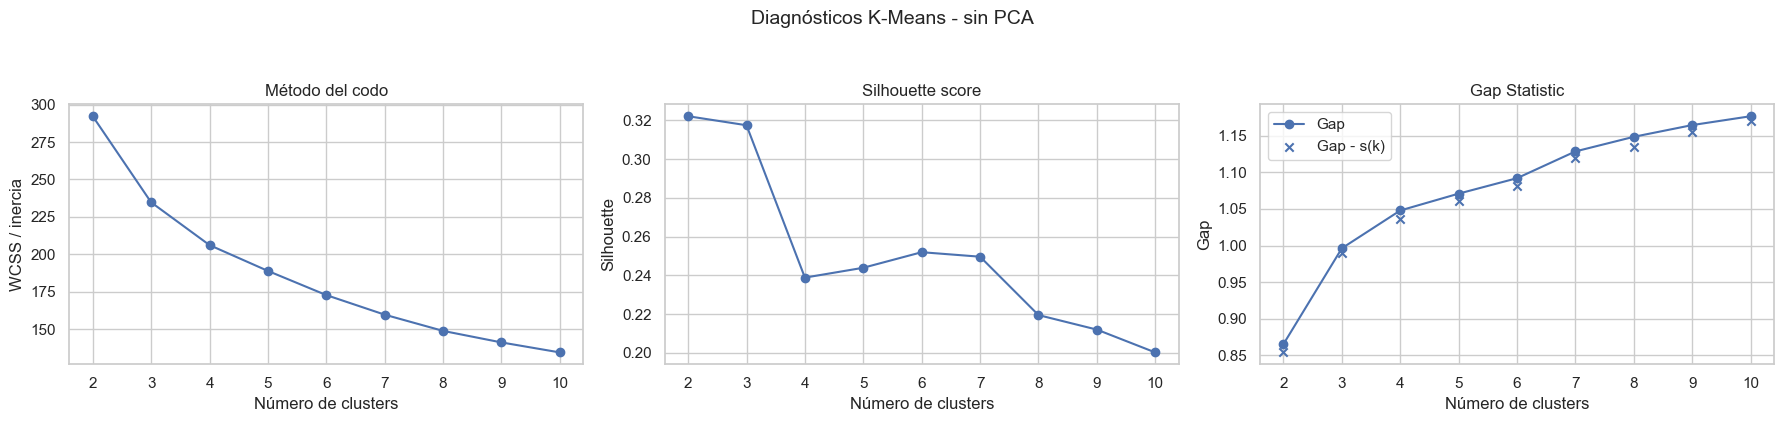

In [75]:
resultados_sin_pca, resumen_sin_pca = evaluar_kmeans(
    X_sin_pca,
    k_min=2,
    k_max=10,
    sample_size=1500,
    random_state=RANDOM_STATE,
    n_references_gap=5
)

display(resultados_sin_pca.round(4))
print("Resumen:", {k: v for k, v in resumen_sin_pca.items() if k != "idx_eval"})

plot_diagnosticos_kmeans(
    resultados_sin_pca,
    titulo="Diagnósticos K-Means - sin PCA",
    guardar_como="cluster_sin_pca_diagnosticos_kmeans.png"
)

In [76]:
# Ajustar si al mirar los gráficos se justifica otro valor.
K_FINAL_SIN_PCA = 2

print("K final elegido para clustering sin PCA:", K_FINAL_SIN_PCA)

kmeans_sin_pca, labels_sin_pca = ajustar_kmeans_final(
    X_sin_pca,
    k=K_FINAL_SIN_PCA,
    nombre_cluster="cluster_sin_pca",
    random_state=RANDOM_STATE
)

df_cluster["cluster_sin_pca"] = labels_sin_pca

K final elegido para clustering sin PCA: 2
Tamaño de clusters para cluster_sin_pca:


,n
0,4502
1,5345


### 8.1. Clustering jerárquico sin PCA, sobre muestra

El algoritmo jerárquico exige calcular muchas distancias entre observaciones. Como el dataset tiene cerca de 10.000 filas, el dendrograma completo sería pesado y poco legible. Por eso se aplica el análisis jerárquico sobre una **muestra**.

Esto sirve para comparar la estructura aproximada con distintos encadenamientos: simple, completo, promedio y Ward.

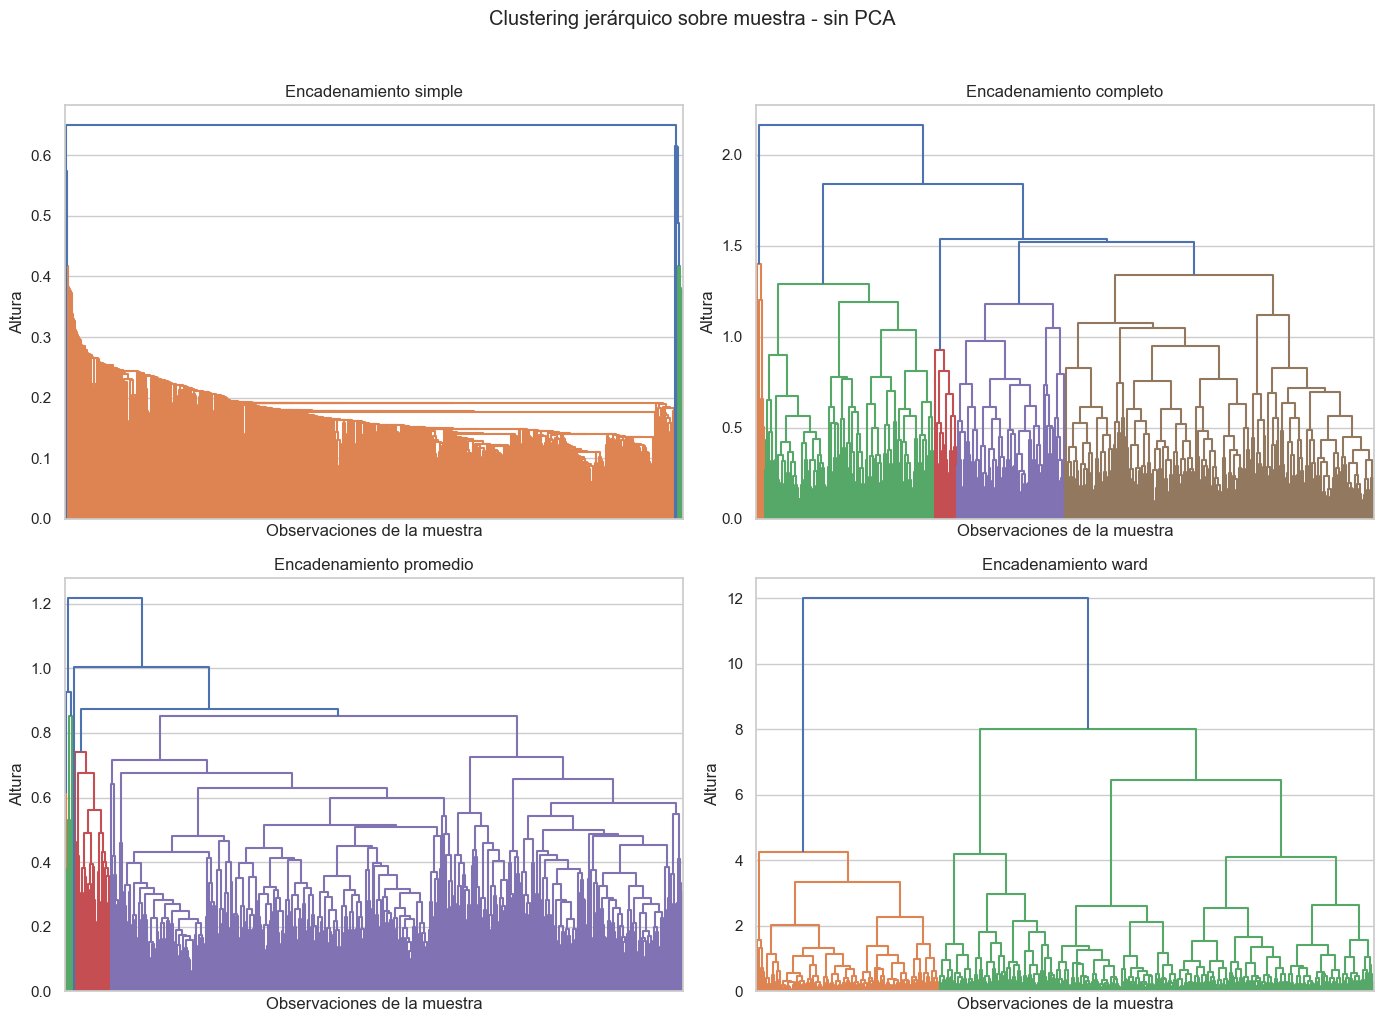

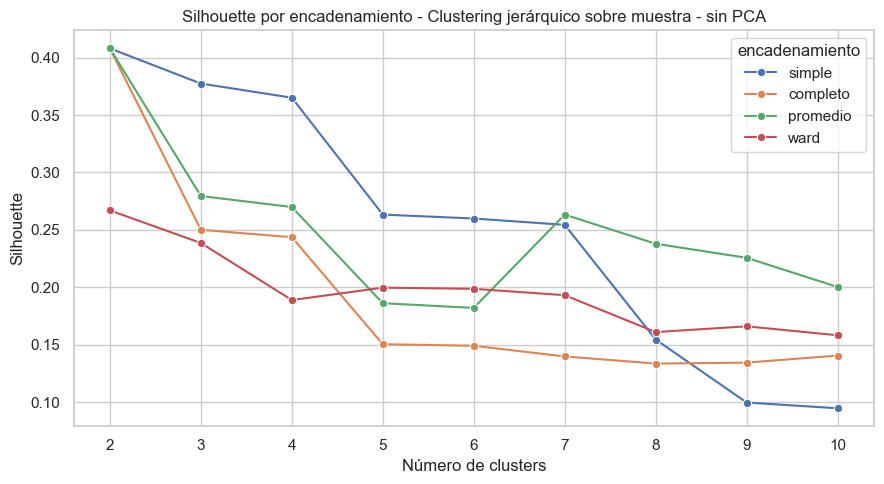

Tamaño de clusters Ward en muestra, k=2:


,n
0,563
1,237


Coeficientes cofenéticos:


,encadenamiento,coeficiente_cofenetico
2,promedio,0.6565
1,completo,0.5743
3,ward,0.5295
0,simple,0.4031


Silhouette por encadenamiento:


encadenamiento,completo,promedio,simple,ward
k,,,,
2,0.4080,0.4080,0.4080,0.2670
3,0.2501,0.2795,0.3774,0.2386
4,0.2436,0.2699,0.3651,0.1889
5,0.1505,0.1862,0.2633,0.1997
6,0.1491,0.1820,0.2599,0.1987
7,0.1398,0.2633,0.2544,0.1931
8,0.1336,0.2379,0.1545,0.1610
9,0.1344,0.2257,0.0997,0.1660
10,0.1405,0.2003,0.0947,0.1582


In [77]:
jerarquico_sin_pca = analisis_jerarquico_muestra(
    X_sin_pca,
    k_final=K_FINAL_SIN_PCA,
    titulo="Clustering jerárquico sobre muestra - sin PCA",
    sample_size=800,
    random_state=RANDOM_STATE,
    guardar_como="cluster_sin_pca_dendrogramas_muestra.png"
)

print("Coeficientes cofenéticos:")
display(jerarquico_sin_pca["cofenetico"].round(4))

print("Silhouette por encadenamiento:")
display(jerarquico_sin_pca["silhouette"].pivot(index="k", columns="encadenamiento", values="silhouette").round(4))

## 9. Perfil de clusters sin PCA

Se describen los clusters usando:

- las variables numéricas activas;
- la variable derivada `posiciones_ganadas`;
- variables categóricas suplementarias como `resultado_grupo`, `largada_grupo`, `status_grupo` y `decada`.

In [78]:
variables_perfil_numericas = variables_cluster_base + ["posiciones_ganadas"]

perfil_sin_pca = perfil_numerico(df_cluster, "cluster_sin_pca", variables_perfil_numericas)
display(perfil_sin_pca)

perfil_sin_pca.to_csv(PROCESSED_DIR / "formula1_cluster_perfil_numerico_sin_pca.csv")

grid                               positionOrder                                laps                                 \
                count    mean median    std min max         count    mean median    std min max count    mean median     std min max   
cluster_sin_pca                                                                                                                        
0                4502   6.188    6.0  4.050   0  24          4502   5.792    5.0  3.790   1  21  4502  60.095   58.0  10.482   0  87   
1                5345  14.788   15.0  4.763   0  24          5345  15.330   15.0  3.979   4  24  5345  46.219   53.0  21.838   0  87   

                driver_age                                        circuit_alt                                     \
                     count    mean  median    std     min     max       count     mean median      std min   max   
cluster_sin_pca                                                                                                    
0                     4502  28.993  28.600  4.920  17.492  43.893        4502  213.402  103.0  367.266  -7  2227   
1                     5345  27.661  26.642  5.018  17.454  43.874        5345  204.225  108.0  340.725  -7  2227   

                driver_championship_position                                  driver_championship_wins                                  \
                                       count    mean median    std  min   max                    count   mean median    std  min   max   
cluster_sin_pca                                                                                                                          
0                                       4502   6.086    6.0  3.748  1.0  20.0                     4502  1.021    0.0  2.092  0.0  19.0   
1                                       5345  15.442   16.0  4.781  1.0  27.0                     5345  0.047    0.0  0.337  0.0  11.0   

                posiciones_ganadas                               
                             count   mean median    std min max  
cluster_sin_pca                                                  
0                             4502  0.396    0.0  4.813 -20  21  
1                             5345 -0.542    0.0  6.417 -24  19

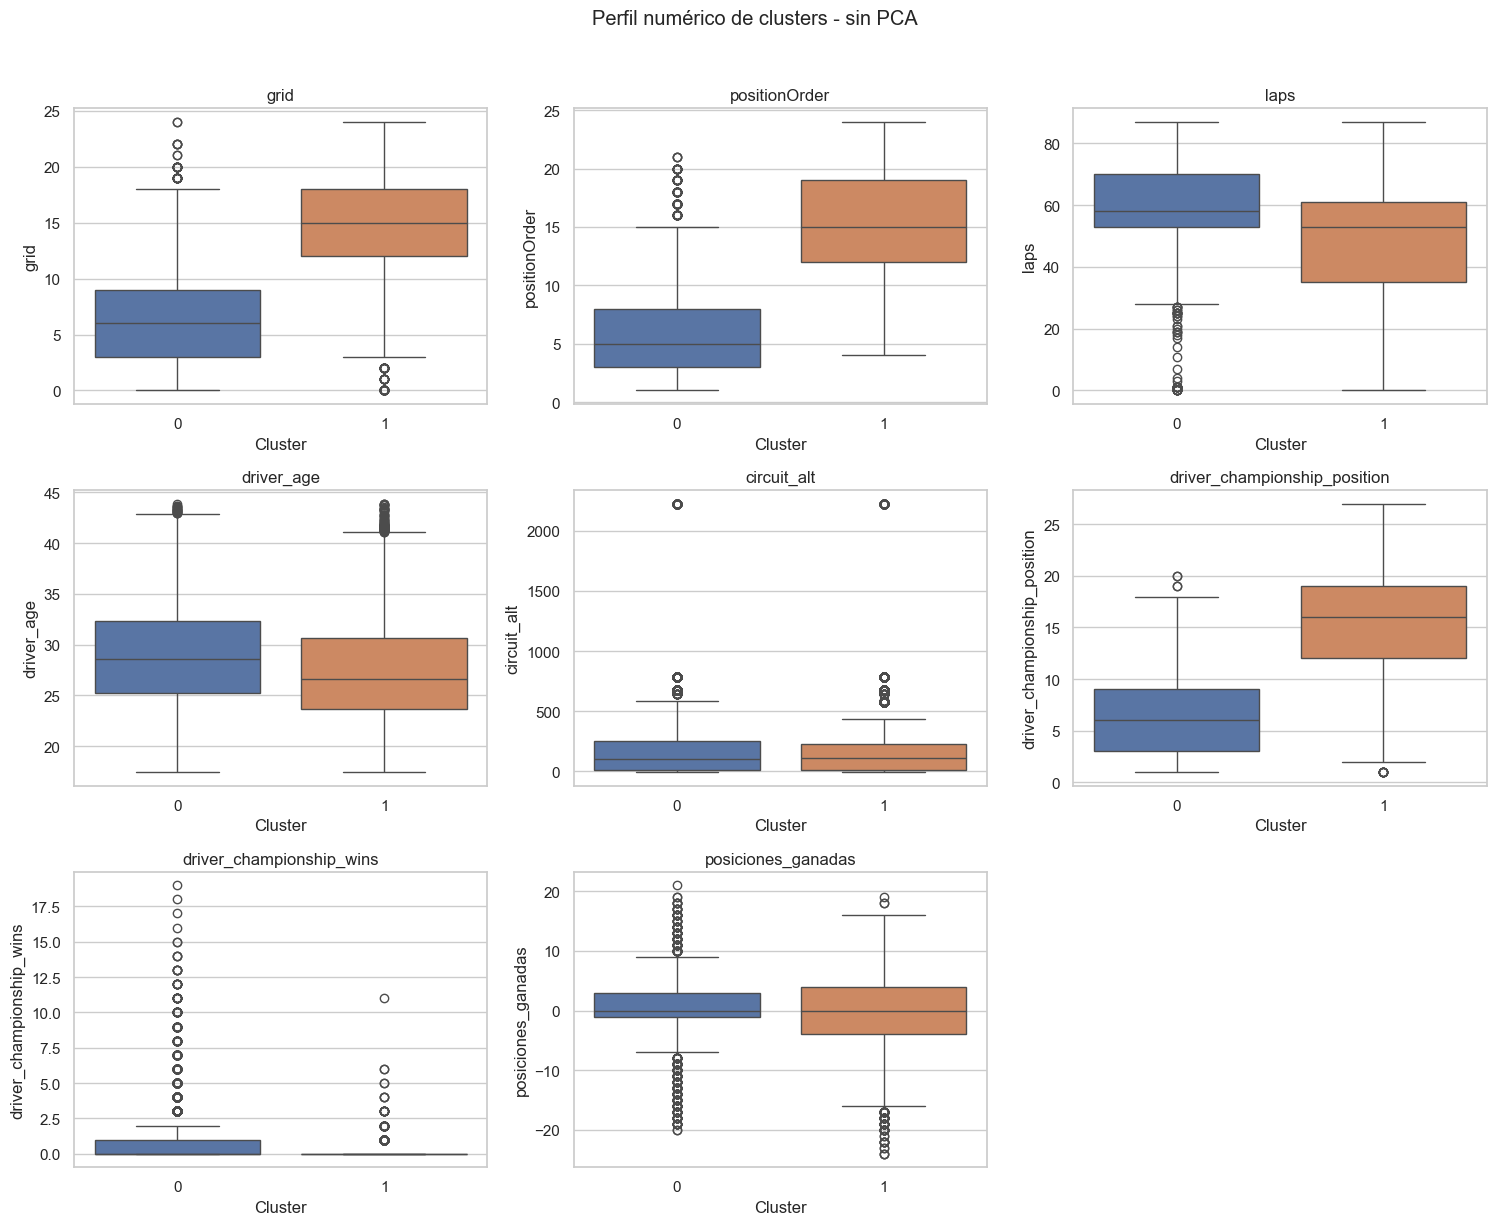

In [79]:
plot_boxplots_clusters(
    df_cluster,
    cluster_col="cluster_sin_pca",
    variables=variables_perfil_numericas,
    titulo="Perfil numérico de clusters - sin PCA",
    guardar_como="cluster_sin_pca_boxplots.png"
)


Distribución de resultado_grupo por cluster sin PCA


resultado_grupo,Fuera del top 10,Ganador,Podio,Top 10
cluster_sin_pca,,,,
0,0.098,0.106,0.211,0.584
1,0.871,0.000,0.000,0.129


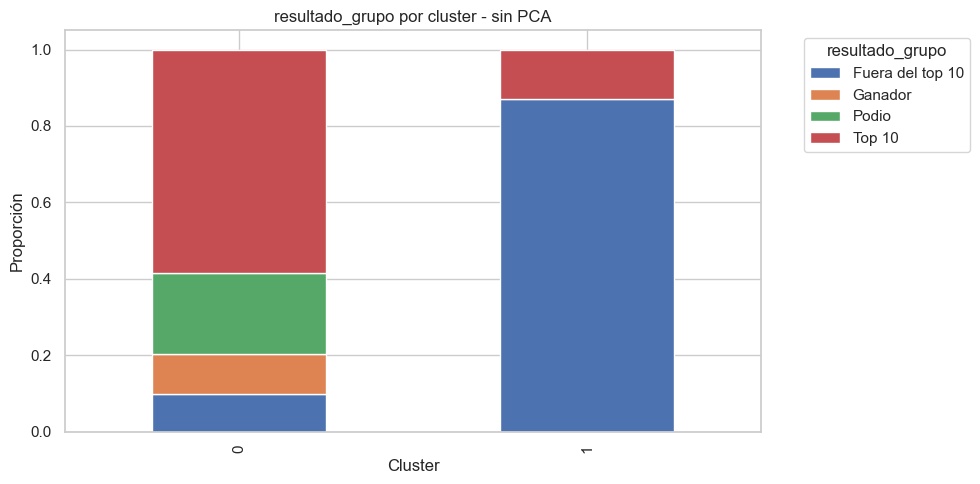


Distribución de largada_grupo por cluster sin PCA


largada_grupo,Fondo,Pit lane / no largó,Pole,Top 10,Top 5
cluster_sin_pca,,,,,
0,0.150,0.010,0.103,0.359,0.378
1,0.819,0.008,0.002,0.137,0.034


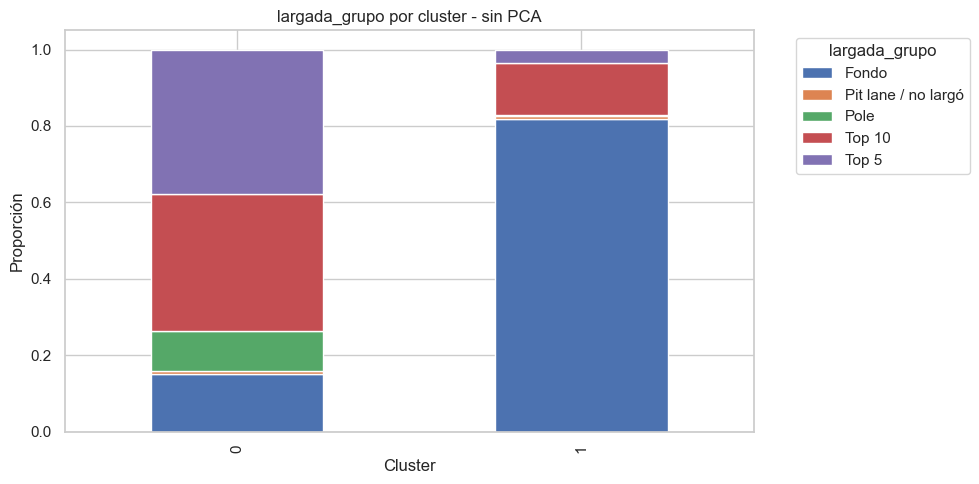


Distribución de status_grupo por cluster sin PCA


status_grupo,Abandono mecánico,Clasificado / terminó,Incidente / abandono,Otro
cluster_sin_pca,,,,
0,0.022,0.956,0.015,0.007
1,0.157,0.633,0.164,0.046


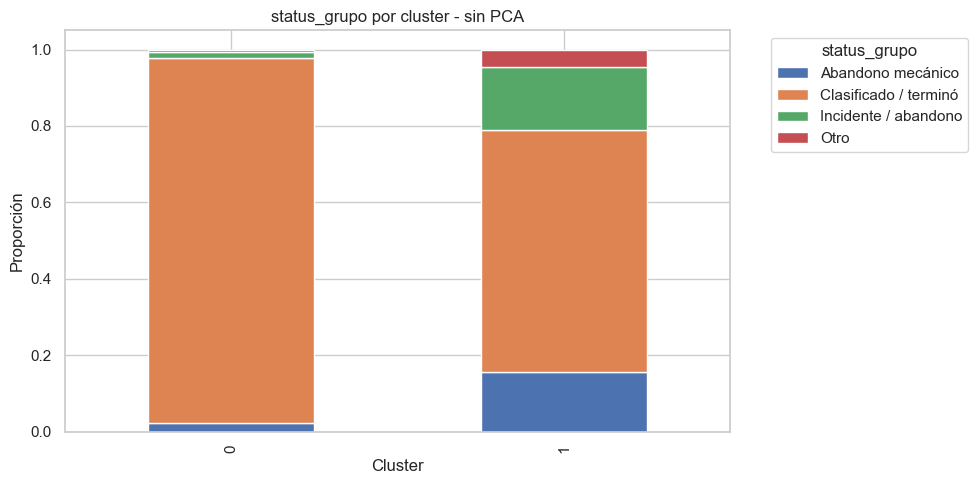


Distribución de decada por cluster sin PCA


decada,2000s,2010s,2020s
cluster_sin_pca,,,
0,0.354,0.411,0.235
1,0.350,0.450,0.200


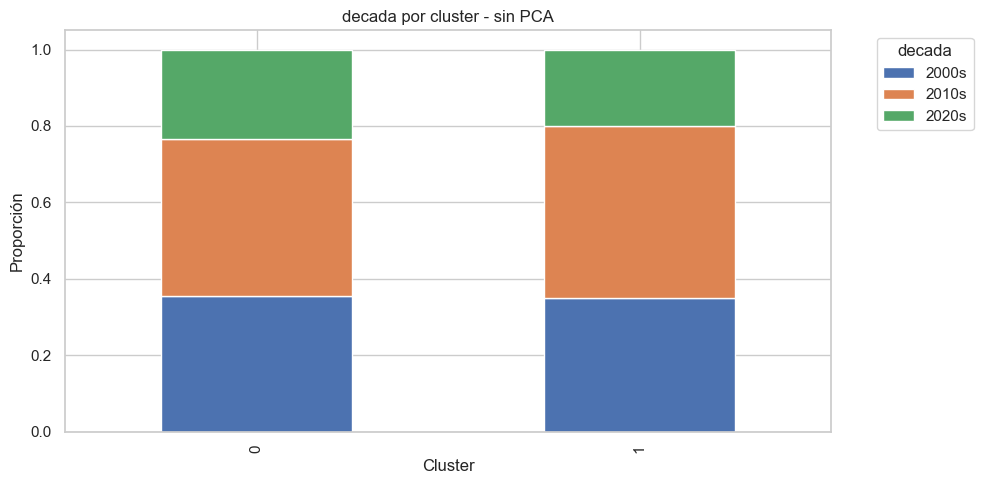

In [80]:
for var_cat in ["resultado_grupo", "largada_grupo", "status_grupo", "decada"]:
    if var_cat in df_cluster.columns:
        print("\n", "="*80)
        print(f"Distribución de {var_cat} por cluster sin PCA")
        tabla = perfil_categorico(df_cluster, "cluster_sin_pca", var_cat)
        display(tabla)
        tabla.to_csv(PROCESSED_DIR / f"formula1_cluster_sin_pca_{var_cat}.csv")

        plot_categorica_fill(
            df_cluster,
            cluster_col="cluster_sin_pca",
            variable_cat=var_cat,
            titulo=f"{var_cat} por cluster - sin PCA",
            guardar_como=f"cluster_sin_pca_{var_cat}.png"
        )

## 10. Clustering con PCA

Ahora se repite el análisis usando la matriz de scores de PCA. En este caso, cada observación ya está representada por pocas componentes principales.

Este enfoque puede ser útil porque:

- reduce redundancia entre variables originales;
- resume la información en ejes interpretables;
- puede estabilizar el clustering si las variables originales están correlacionadas.

Pero también puede perder información si se descartan componentes relevantes.

,k,inercia,silhouette,proporcion_cluster_mas_chico,gap,gap_menos_s
0,2,5717.9266,0.3053,0.420,1.3308,1.3170
1,3,4658.9843,0.2997,0.152,1.3595,1.3471
2,4,3929.0895,0.3159,0.016,1.3770,1.3655
3,5,3262.9440,0.3056,0.016,1.4597,1.4490
4,6,2850.9628,0.2698,0.016,1.4892,1.4795
5,7,2576.6647,0.2703,0.016,1.4887,1.4730
6,8,2367.3439,0.2590,0.016,1.5011,1.4930
7,9,2203.7169,0.2689,0.016,1.5050,1.4996
8,10,2046.9860,0.2652,0.016,1.5133,1.5044


Resumen: {'k_silhouette_sugerido': 2, 'k_gap': 6, 'n_eval': 1500}


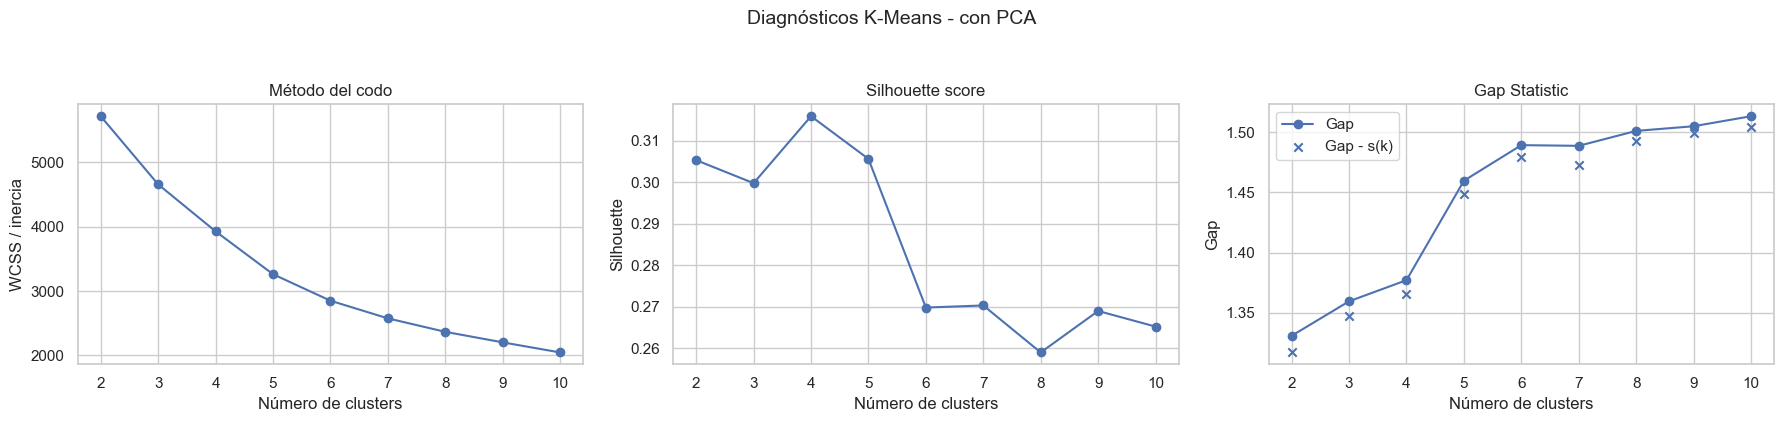

In [81]:
resultados_con_pca, resumen_con_pca = evaluar_kmeans(
    X_con_pca,
    k_min=2,
    k_max=10,
    sample_size=1500,
    random_state=RANDOM_STATE,
    n_references_gap=5
)

display(resultados_con_pca.round(4))
print("Resumen:", {k: v for k, v in resumen_con_pca.items() if k != "idx_eval"})

plot_diagnosticos_kmeans(
    resultados_con_pca,
    titulo="Diagnósticos K-Means - con PCA",
    guardar_como="cluster_con_pca_diagnosticos_kmeans.png"
)

In [82]:
# Ajustar si al mirar los gráficos se justifica otro valor.
K_FINAL_CON_PCA = 4

print("K final elegido para clustering con PCA:", K_FINAL_CON_PCA)

kmeans_con_pca, labels_con_pca = ajustar_kmeans_final(
    X_con_pca,
    k=K_FINAL_CON_PCA,
    nombre_cluster="cluster_con_pca",
    random_state=RANDOM_STATE
)

df_cluster["cluster_con_pca"] = labels_con_pca

K final elegido para clustering con PCA: 4
Tamaño de clusters para cluster_con_pca:


,n
0,4605
1,1478
2,3585
3,179


### 10.1. Clustering jerárquico con PCA, sobre muestra

Se repite el análisis jerárquico sobre la matriz PCA. Esto permite ver si la estructura jerárquica cambia al trabajar sobre las componentes principales.

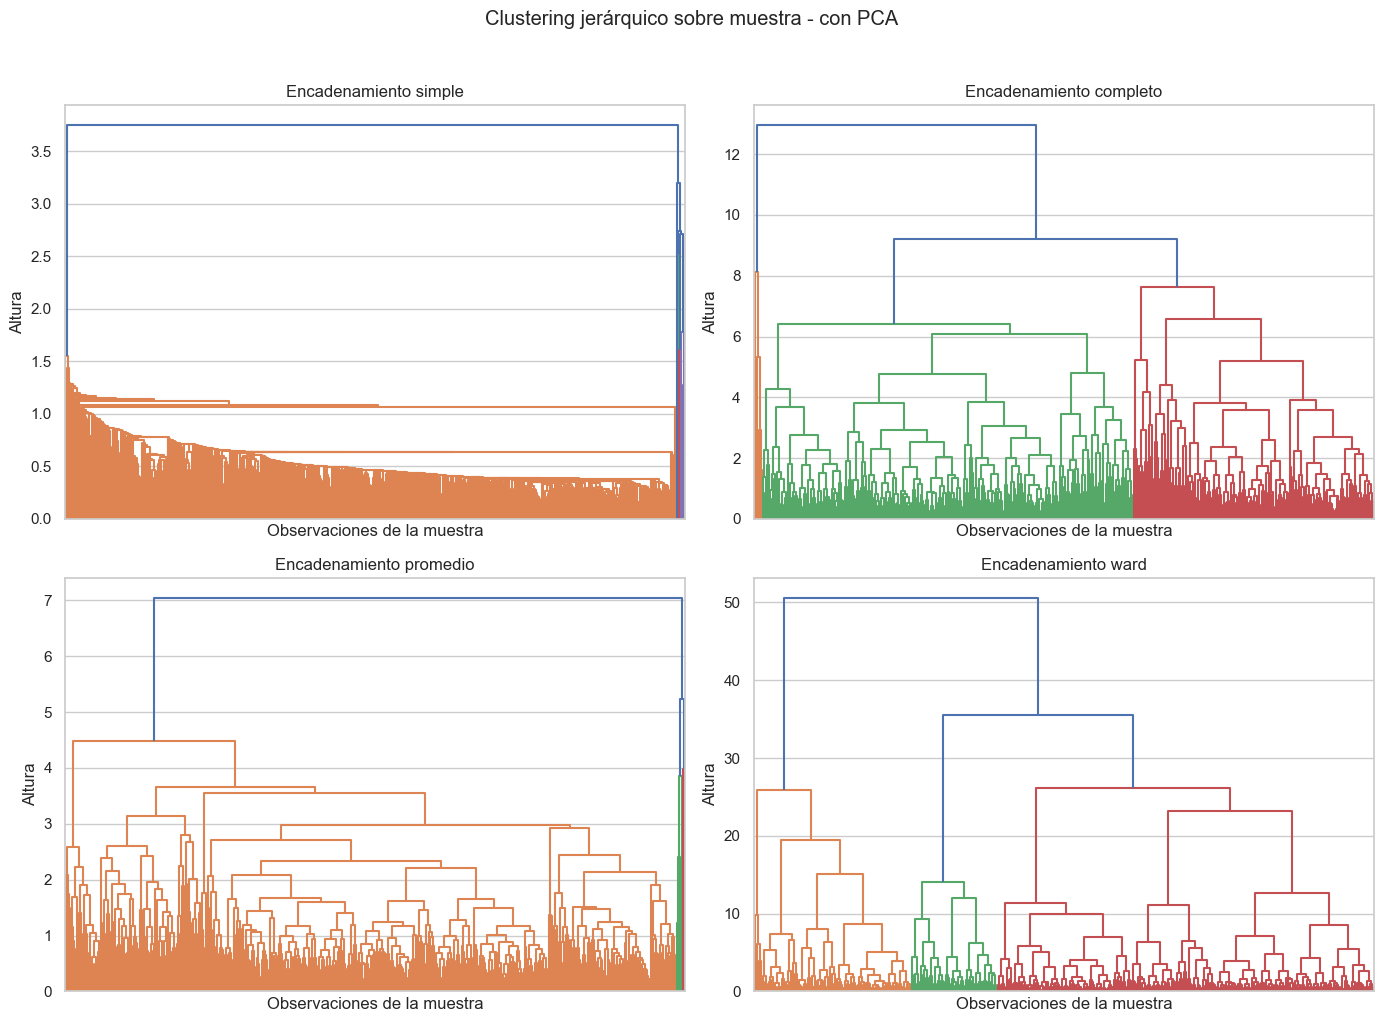

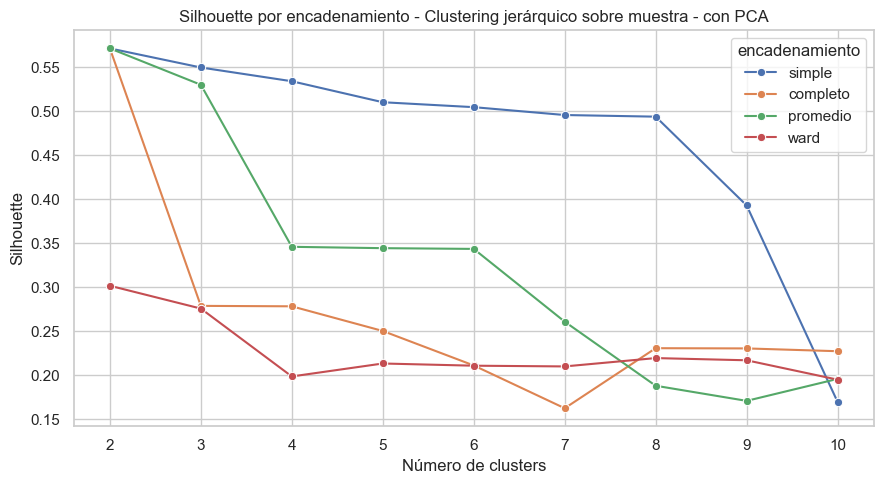

Tamaño de clusters Ward en muestra, k=4:


,n
0,313
1,173
2,203
3,111


Coeficientes cofenéticos:


,encadenamiento,coeficiente_cofenetico
2,promedio,0.7488
1,completo,0.6041
0,simple,0.5962
3,ward,0.5509


Silhouette por encadenamiento:


encadenamiento,completo,promedio,simple,ward
k,,,,
2,0.5715,0.5715,0.5715,0.3018
3,0.2789,0.5302,0.5498,0.2758
4,0.2784,0.3460,0.5342,0.1987
5,0.2504,0.3445,0.5104,0.2134
6,0.2112,0.3436,0.5048,0.2109
7,0.1625,0.2609,0.4958,0.2101
8,0.2308,0.1881,0.4940,0.2195
9,0.2305,0.1709,0.3930,0.2170
10,0.2274,0.1959,0.1697,0.1950


In [83]:
jerarquico_con_pca = analisis_jerarquico_muestra(
    X_con_pca,
    k_final=K_FINAL_CON_PCA,
    titulo="Clustering jerárquico sobre muestra - con PCA",
    sample_size=800,
    random_state=RANDOM_STATE,
    guardar_como="cluster_con_pca_dendrogramas_muestra.png"
)

print("Coeficientes cofenéticos:")
display(jerarquico_con_pca["cofenetico"].round(4))

print("Silhouette por encadenamiento:")
display(jerarquico_con_pca["silhouette"].pivot(index="k", columns="encadenamiento", values="silhouette").round(4))

## 11. Perfil de clusters con PCA

Aunque el algoritmo usa componentes principales, los clusters se interpretan nuevamente con las variables originales. Esto evita describir los grupos solo como “alto CP1” o “bajo CP2” y permite traducirlos al problema de Fórmula 1.

In [84]:
perfil_con_pca = perfil_numerico(df_cluster, "cluster_con_pca", variables_perfil_numericas)
display(perfil_con_pca)

perfil_con_pca.to_csv(PROCESSED_DIR / "formula1_cluster_perfil_numerico_con_pca.csv")

grid                               positionOrder                                laps                                 \
                count    mean median    std min max         count    mean median    std min max count    mean median     std min max   
cluster_con_pca                                                                                                                        
0                4605  14.775   15.0  4.419   0  24          4605  12.926   13.0  3.803   3  24  4605  58.326   57.0   9.040  26  87   
1                1478  12.152   13.0  5.916   0  24          1478  19.279   19.0  2.475   2  24  1478  14.631   12.0  13.261   0  56   
2                3585   5.310    5.0  3.524   0  24          3585   5.048    4.0  3.523   1  21  3585  60.197   58.0   9.367   0  87   
3                 179  10.425   10.0  5.912   0  22           179  10.620   11.0  5.836   1  22   179  64.615   70.0  16.561   0  71   

                driver_age                                        circuit_alt                                         \
                     count    mean  median    std     min     max       count      mean  median      std   min   max   
cluster_con_pca                                                                                                        
0                     4605  27.436  26.360  4.969  17.454  43.893        4605   169.974   103.0  225.055    -7   785   
1                     1478  28.236  27.626  5.001  17.550  43.721        1478   177.923   109.0  220.018    -7   785   
2                     3585  29.358  29.018  4.852  18.067  43.682        3585   169.591   103.0  224.158    -7   785   
3                      179  28.212  27.113  5.517  18.086  43.247         179  2227.000  2227.0    0.000  2227  2227   

                driver_championship_position                                  driver_championship_wins                                  \
                                       count    mean median    std  min   max                    count   mean median    std  min   max   
cluster_con_pca                                                                                                                          
0                                       4605  15.191   15.0  4.474  1.0  27.0                     4605  0.010    0.0  0.104  0.0   2.0   
1                                       1478  13.400   14.0  5.901  1.0  27.0                     1478  0.175    0.0  0.662  0.0  11.0   
2                                       3585   5.087    5.0  3.104  1.0  16.0                     3585  1.221    0.0  2.219  0.0  19.0   
3                                        179  10.821   11.0  6.143  1.0  24.0                      179  0.927    0.0  2.502  0.0  16.0   

                posiciones_ganadas                               
                             count   mean median    std min max  
cluster_con_pca                                                  
0                             4605  1.849    2.0  4.880 -20  19  
1                             1478 -7.128   -7.0  6.094 -24   8  
2                             3585  0.262    0.0  4.321 -20  21  
3                              179 -0.196    0.0  4.792 -17  12

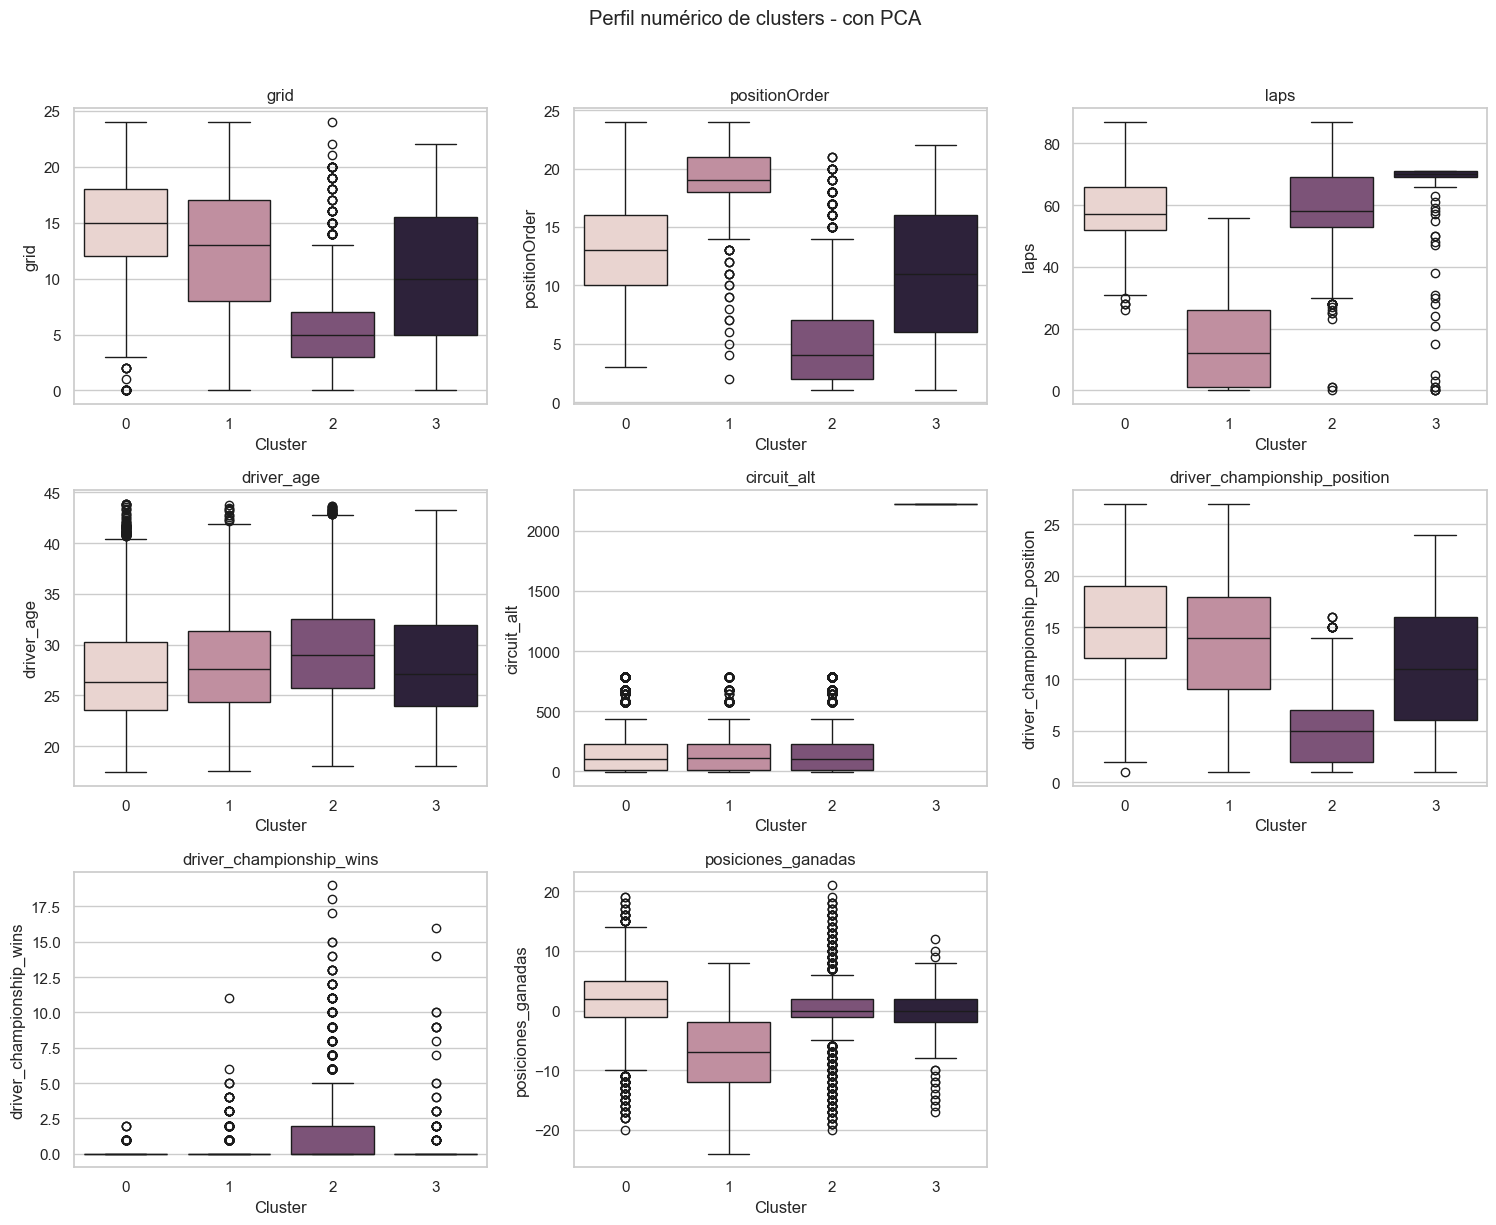

In [85]:
plot_boxplots_clusters(
    df_cluster,
    cluster_col="cluster_con_pca",
    variables=variables_perfil_numericas,
    titulo="Perfil numérico de clusters - con PCA",
    guardar_como="cluster_con_pca_boxplots.png"
)


Distribución de resultado_grupo por cluster con PCA


resultado_grupo,Fuera del top 10,Ganador,Podio,Top 10
cluster_con_pca,,,,
0,0.714,0.000,0.002,0.283
1,0.993,0.000,0.001,0.007
2,0.070,0.131,0.258,0.541
3,0.508,0.050,0.095,0.346


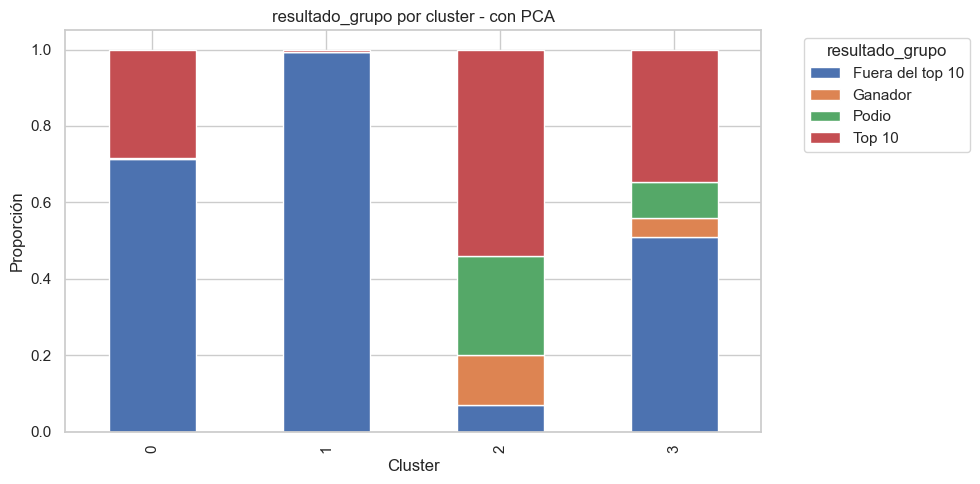


Distribución de largada_grupo por cluster con PCA


largada_grupo,Fondo,Pit lane / no largó,Pole,Top 10,Top 5
cluster_con_pca,,,,,
0,0.823,0.006,0.000,0.159,0.012
1,0.608,0.020,0.020,0.228,0.125
2,0.078,0.008,0.121,0.344,0.449
3,0.492,0.011,0.050,0.251,0.196


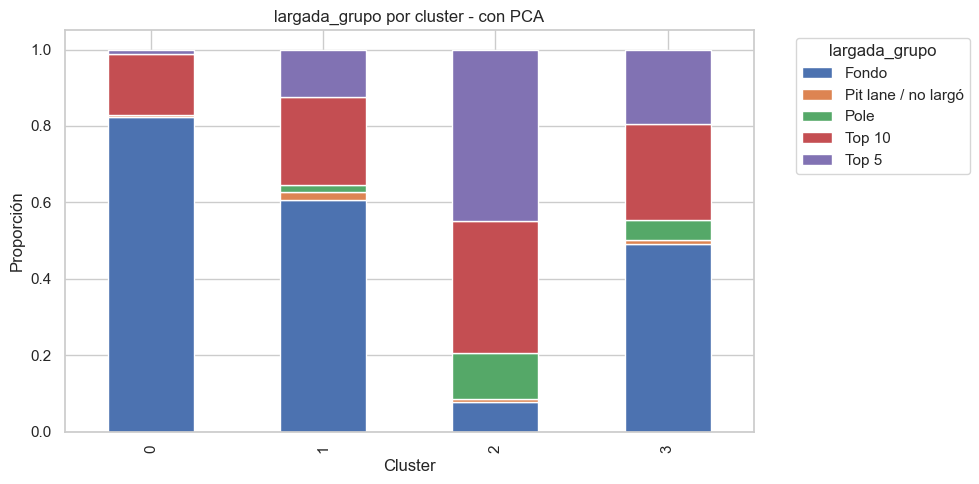


Distribución de status_grupo por cluster con PCA


status_grupo,Abandono mecánico,Clasificado / terminó,Incidente / abandono,Otro
cluster_con_pca,,,,
0,0.061,0.878,0.045,0.017
1,0.396,0.021,0.461,0.122
2,0.018,0.965,0.011,0.005
3,0.067,0.849,0.078,0.006


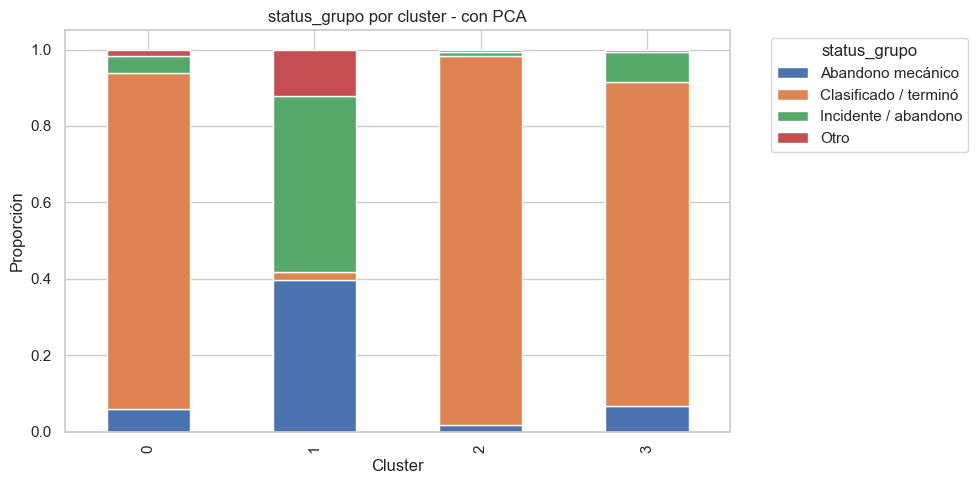


Distribución de decada por cluster con PCA


decada,2000s,2010s,2020s
cluster_con_pca,,,
0,0.329,0.456,0.215
1,0.453,0.394,0.153
2,0.358,0.411,0.231
3,0.000,0.559,0.441


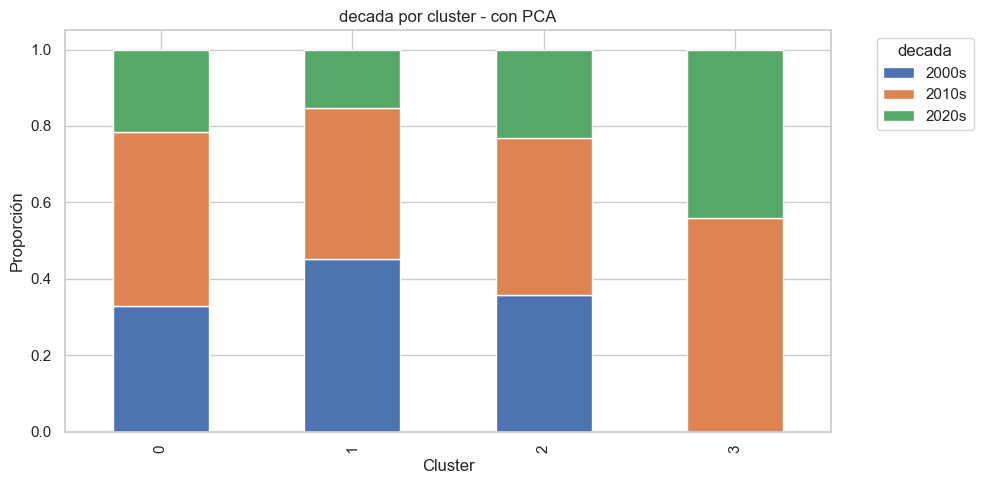

In [86]:
for var_cat in ["resultado_grupo", "largada_grupo", "status_grupo", "decada"]:
    if var_cat in df_cluster.columns:
        print("\n", "="*80)
        print(f"Distribución de {var_cat} por cluster con PCA")
        tabla = perfil_categorico(df_cluster, "cluster_con_pca", var_cat)
        display(tabla)
        tabla.to_csv(PROCESSED_DIR / f"formula1_cluster_con_pca_{var_cat}.csv")

        plot_categorica_fill(
            df_cluster,
            cluster_col="cluster_con_pca",
            variable_cat=var_cat,
            titulo=f"{var_cat} por cluster - con PCA",
            guardar_como=f"cluster_con_pca_{var_cat}.png"
        )

## 12. Comparación entre clustering sin PCA y con PCA

Ahora se compara si ambas estrategias producen grupos parecidos.

Se usan dos herramientas:

1. **Tabla cruzada:** muestra cómo se reparten las observaciones entre los clusters de ambos métodos.
2. **Adjusted Rand Index (ARI):** mide el acuerdo entre particiones, corrigiendo por azar. Toma valores cercanos a 1 cuando las particiones son muy similares y valores cercanos a 0 cuando el acuerdo no supera mucho al azar.

In [87]:
comparacion_clusters = pd.crosstab(
    df_cluster["cluster_sin_pca"],
    df_cluster["cluster_con_pca"],
    rownames=["Sin PCA"],
    colnames=["Con PCA"]
)

comparacion_clusters_norm = pd.crosstab(
    df_cluster["cluster_sin_pca"],
    df_cluster["cluster_con_pca"],
    normalize="index"
).round(3)

ari = adjusted_rand_score(df_cluster["cluster_sin_pca"], df_cluster["cluster_con_pca"])

print("Tabla cruzada - cantidades")
display(comparacion_clusters)

print("Tabla cruzada - proporciones por cluster sin PCA")
display(comparacion_clusters_norm)

print(f"Adjusted Rand Index: {ari:.4f}")

comparacion_clusters.to_csv(PROCESSED_DIR / "formula1_cluster_comparacion_sin_pca_vs_con_pca.csv")
comparacion_clusters_norm.to_csv(PROCESSED_DIR / "formula1_cluster_comparacion_sin_pca_vs_con_pca_normalizada.csv")

Tabla cruzada - cantidades


Con PCA,0,1,2,3
Sin PCA,,,,
0,771,60,3579,92
1,3834,1418,6,87


Tabla cruzada - proporciones por cluster sin PCA


cluster_con_pca,0,1,2,3
cluster_sin_pca,,,,
0,0.171,0.013,0.795,0.020
1,0.717,0.265,0.001,0.016


Adjusted Rand Index: 0.4884


## 13. Visualización en el plano PCA

Para comparar visualmente ambos enfoques, se grafican las observaciones en el plano CP1-CP2 y se colorean según los clusters obtenidos.

Aunque el clustering sin PCA no se calculó en el espacio PCA, proyectarlo en este plano ayuda a comparar visualmente las particiones.

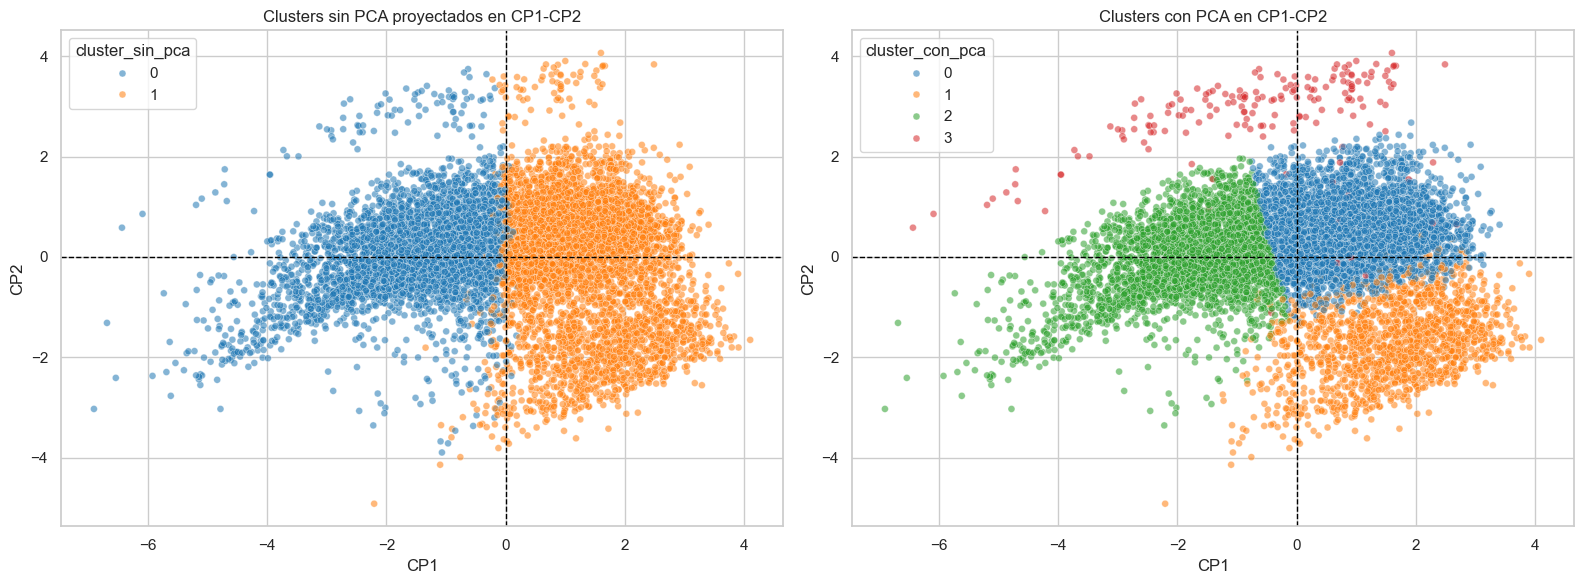

In [88]:
if X_con_pca_df.shape[1] >= 2:
    df_plot_pca = pd.concat(
        [df_cluster.reset_index(drop=True), X_con_pca_df.reset_index(drop=True)],
        axis=1
    )

    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    sns.scatterplot(
        data=df_plot_pca,
        x="CP1", y="CP2",
        hue="cluster_sin_pca",
        palette="tab10",
        alpha=0.55,
        s=25,
        ax=axs[0]
    )
    axs[0].axhline(0, color="black", linestyle="--", linewidth=1)
    axs[0].axvline(0, color="black", linestyle="--", linewidth=1)
    axs[0].set_title("Clusters sin PCA proyectados en CP1-CP2")

    sns.scatterplot(
        data=df_plot_pca,
        x="CP1", y="CP2",
        hue="cluster_con_pca",
        palette="tab10",
        alpha=0.55,
        s=25,
        ax=axs[1]
    )
    axs[1].axhline(0, color="black", linestyle="--", linewidth=1)
    axs[1].axvline(0, color="black", linestyle="--", linewidth=1)
    axs[1].set_title("Clusters con PCA en CP1-CP2")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "cluster_comparacion_en_plano_pca.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("La matriz PCA tiene menos de dos componentes. No se puede graficar CP1 vs CP2.")

## 14. Guardar resultados finales

Se guardan las bases con las etiquetas de cluster para poder usarlas en el informe y en análisis posteriores.

In [89]:
# Base completa de clustering con ambas etiquetas.
ruta_resultados = PROCESSED_DIR / "formula1_cluster_resultados.csv"
df_cluster.to_csv(ruta_resultados, index=False)

# Versiones separadas por enfoque.
cols_id = [c for c in ["resultId", "raceId", "driverId", "constructorId", "year", "driver_name", "constructor_name", "race_name"] if c in df_cluster.columns]

cols_sin_pca = cols_id + variables_cluster_base + ["posiciones_ganadas", "cluster_sin_pca"]
cols_con_pca = cols_id + variables_cluster_base + ["posiciones_ganadas", "cluster_con_pca"]

df_cluster[cols_sin_pca].to_csv(PROCESSED_DIR / "formula1_cluster_sin_pca_resultados.csv", index=False)
df_cluster[cols_con_pca].to_csv(PROCESSED_DIR / "formula1_cluster_con_pca_resultados.csv", index=False)

# Variables utilizadas.
pd.DataFrame({"variable": variables_cluster_base}).to_csv(
    PROCESSED_DIR / "formula1_cluster_variables_activas.csv", index=False
)

print("Archivos guardados:")
print("-", ruta_resultados)
print("-", PROCESSED_DIR / "formula1_cluster_sin_pca_resultados.csv")
print("-", PROCESSED_DIR / "formula1_cluster_con_pca_resultados.csv")
print("-", PROCESSED_DIR / "formula1_cluster_variables_activas.csv")

Archivos guardados:
- /Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado/data/processed/formula1_cluster_resultados.csv
- /Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado/data/processed/formula1_cluster_sin_pca_resultados.csv
- /Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado/data/processed/formula1_cluster_con_pca_resultados.csv
- /Users/juani/Desktop/Facultad/3er año/Analisis Multivariado y Descrubrimiento de Patrones/Analisis-multivariado/data/processed/formula1_cluster_variables_activas.csv


## 15. Interpretación para el informe

Completar esta sección después de correr el notebook y revisar los perfiles.

### Clustering sin PCA

- **Cluster 0:** describir según posición final, posición de largada, vueltas completadas, edad y posición en campeonato.
- **Cluster 1:** describir diferencias respecto al cluster 0.
- **Cluster 2:** si aparece, identificar si representa rendimiento alto, medio, bajo o casos atípicos.

### Clustering con PCA

- Comparar si los clusters son parecidos a los obtenidos sin PCA.
- Revisar si el uso de PCA genera grupos más limpios o si mezcla perfiles distintos.
- Usar la tabla cruzada y el ARI para justificar el grado de acuerdo entre ambos enfoques.

### Decisión final recomendada

La decisión final no debe basarse solo en el valor de silhouette. También hay que mirar si los clusters son interpretables en términos del problema.

Una posible redacción:

> Se compararon dos estrategias de clustering: una aplicada directamente sobre las variables numéricas escaladas y otra aplicada sobre la matriz de componentes principales. La comparación permitió evaluar si la reducción dimensional mediante PCA conservaba la estructura de grupos presente en los datos originales. La elección final del enfoque se realizó considerando tanto métricas internas de validación como la interpretabilidad de los perfiles obtenidos.